# 1. Introduction

## User Behavior Analysis & Segmentation

This notebook explores user behavior patterns on a video streaming platform.
The objective is to identify meaningful user segments based on engagement,
content consumption, and subscription characteristics, and to understand
how these segments relate to churn risk.

This analysis focuses on behavioral insights rather than predictive modeling.


# 2. Data Loading & Basic Preparation

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

users = pd.read_csv("/Users/injoo/Desktop/netflix_project/users_preprocessed.csv")
movies = pd.read_csv("/Users/injoo/Desktop/netflix_project/movies_preprocessed.csv")
watch = pd.read_csv("/Users/injoo/Desktop/netflix_project/watch_history_preprocessed.csv")

# Date parsing
users["subscription_start_date"] = pd.to_datetime(users["subscription_start_date"], errors="coerce")
movies["added_to_platform"] = pd.to_datetime(movies["added_to_platform"], errors="coerce")
watch["watch_date"] = pd.to_datetime(watch["watch_date"], errors="coerce")

print(users.shape, movies.shape, watch.shape)

(9981, 17) (984, 21) (97048, 13)


We work with three tables:
- users: demographic and subscription information
- movies: content metadata
- watch_history: user viewing sessions


# 3. Feature Engineering (Recent Behavior)

In [7]:
# Join movie genre
watch = watch.merge(
    movies[["movie_id", "genre_primary"]],
    on="movie_id",
    how="left"
)

# Recent 30-day window
max_date = watch["watch_date"].max()
start_30d = max_date - pd.Timedelta(days=30)

recent_watch = watch[watch["watch_date"] >= start_30d]

behavior_30d = (
    recent_watch.groupby("user_id")
    .agg(
        freq_30d=("session_id", "count"),
        avg_watch_minutes=("watch_duration_minutes", "mean"),
        completion_rate=("progress_percentage", "mean"),
        active_days=("watch_date", lambda x: x.dt.date.nunique())
    )
    .reset_index()
)

users_beh = users.merge(behavior_30d, on="user_id", how="left")
users_beh.fillna(0, inplace=True)


We focus on **recent activity (last 30 days)** to better reflect current engagement:
- Frequency of sessions
- Average watch time
- Completion rate
- Number of active days


# 4. Heavy vs Light Users

### Definition

A user is classified as **Heavy** if at least 2 of the following conditions are met:
- Session frequency in the top 30% of their subscription plan
- Watch time above the median
- Completion rate ≥ 70%


In [8]:
# Frequency threshold per subscription plan
users_beh["high_freq"] = (
    users_beh.groupby("subscription_plan")["freq_30d"]
    .transform(lambda x: x >= x.quantile(0.7))
)

users_beh["high_time"] = users_beh["avg_watch_minutes"] >= users_beh["avg_watch_minutes"].median()
users_beh["high_completion"] = users_beh["completion_rate"] >= 0.7

criteria = ["high_freq", "high_time", "high_completion"]
users_beh["behavior_segment"] = np.where(
    users_beh[criteria].sum(axis=1) >= 2,
    "Heavy",
    "Light"
)


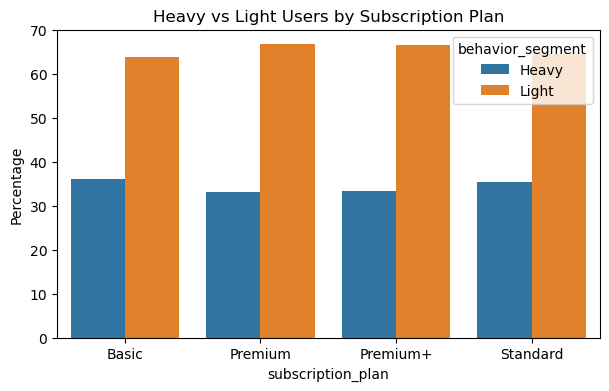

In [10]:
# Visualization
segment_dist = (
    users_beh
    .groupby(["subscription_plan", "behavior_segment"], as_index=False)
    .size()
)

segment_dist["percent"] = (
    segment_dist
    .groupby("subscription_plan")["size"]
    .transform(lambda x: x / x.sum() * 100)
)


plt.figure(figsize=(7,4))
sns.barplot(
    data=segment_dist,
    x="subscription_plan",
    y="percent",
    hue="behavior_segment"
)
plt.title("Heavy vs Light Users by Subscription Plan")
plt.ylabel("Percentage")
plt.show()


# 5. Genre Diversity (Entropy)

Users consuming a wider variety of genres may show stronger long-term engagement.
We quantify this using genre entropy.


In [13]:
genre_counts = (
    watch.dropna(subset=["genre_primary"])
    .groupby(["user_id", "genre_primary"])
    .size()
    .reset_index(name="cnt")
)

total = genre_counts.groupby("user_id")["cnt"].sum()
genre_counts["p"] = genre_counts["cnt"] / genre_counts["user_id"].map(total)

genre_entropy = (
    genre_counts.groupby("user_id")["p"]
    .apply(lambda x: -(x * np.log(x)).sum())
    .reset_index(name="genre_entropy")
)

users_beh = users_beh.merge(
    genre_entropy,
    on="user_id",
    how="left"
)

users_beh["genre_entropy"] = users_beh["genre_entropy"].fillna(0)


users_beh["diversity_segment"] = np.where(
    users_beh["genre_entropy"] >= users_beh["genre_entropy"].quantile(0.7),
    "Diversified",
    "Focused"
)


# 6. Churn Risk (EDA Proxy)

As churn labels are not explicitly available in this dataset,
we define a churn risk proxy: **no activity in the last 30 days**.


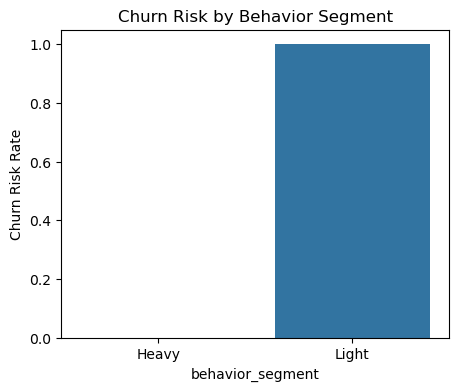

In [15]:
users_beh["churn_risk"] = users_beh["freq_30d"] == 0

churn_summary = (
    users_beh.groupby("behavior_segment")["churn_risk"]
    .mean()
    .reset_index(name="churn_rate")
)

plt.figure(figsize=(5,4))
sns.barplot(data=churn_summary, x="behavior_segment", y="churn_rate")
plt.title("Churn Risk by Behavior Segment")
plt.ylabel("Churn Risk Rate")
plt.show()


In [17]:
users_beh.to_csv("/Users/injoo/Desktop/netflix_project/users_beh.csv", index=False)


# 7. Key Insights

## Key Insights

- Heavy users exhibit significantly lower churn risk than Light users.
- Genre-diversified users are more resilient to churn than genre-focused users.
- Engagement depth matters more than demographic variables.
